# Week 7 Interim — Complex Model: Random Forest Baseline
**CariSurg MedTech Pathways Programme — Mercer General Hospital**

**Random seed:** `42` — same as Week 6. All results in this notebook and the accompanying benchmark table come from a single execution with this seed.  
**Train/test split:** Reused exactly from Week 6 (80/20 stratified on ESI, `random_state=42`).  
**Complex model:** Random Forest (`n_estimators=200`, `max_depth=12`, `class_weight='balanced'`)  

> **Reproducibility:** The split is identical to Week 6 because `RANDOM_SEED = 42` and `stratify=y` are both set. Rerunning this notebook from scratch will reproduce the same train/test indices and therefore the same benchmark comparison.

---

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, recall_score, f1_score, precision_score
)
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print(f'Random seed: {RANDOM_SEED} — same as Week 6')

Random seed: 42 — same as Week 6


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1 — Load Dataset and Define Features

Identical feature set to Week 6. Insurance and employment excluded (proxy-variable bias risk, Week 4 risk register). Disposition excluded — post-triage outcome, not a triage input.

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Carisurg_Triage_Test/yaleemmlc_admissionprediction_triage.csv')
print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')

vitals = [
    'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp',
    'triage_vital_rr', 'triage_vital_o2', 'triage_vital_temp', 'triage_glucose'
]
cc_cols = [c for c in df.columns if c.startswith('cc_')]
feature_cols = vitals + ['age'] + cc_cols

X = df[feature_cols].copy()
y = df['esi'].copy()

print(f'Features: {len(feature_cols)} (7 vitals + age + {len(cc_cols)} chief complaints)')

Dataset: 55,121 rows x 226 columns
Features: 208 (7 vitals + age + 200 chief complaints)


## Step 2 — Reuse Exact Train/Test Split from Week 6

Using the same `RANDOM_SEED = 42` and `stratify=y` ensures the indices are identical to Week 6. This is the only valid way to compare models like-for-like — both see the same training data and are evaluated on the same test set.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f'Training set:  {len(X_train):,} rows')
print(f'Test set:      {len(X_test):,} rows')
print(f'Test ESI 1 count: {(y_test == 1.0).sum()} (should be 16 — confirms same split as Week 6)')

Training set:  44,096 rows
Test set:      11,025 rows
Test ESI 1 count: 16 (should be 16 — confirms same split as Week 6)


## Step 3 — Re-train Week 6 Baselines (with Timing)

Re-running the Week 6 models here so training time and inference time are measured under identical conditions on the same machine — necessary for a fair benchmark comparison.

In [5]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED,
                        class_weight='balanced', solver='lbfgs')
t0 = time.time(); lr.fit(X_train, y_train); lr_train = time.time()-t0
t0 = time.time(); y_pred_lr = lr.predict(X_test); lr_inf = (time.time()-t0)/len(X_test)*1000
print(f'LR trained in {lr_train:.2f}s | Inference: {lr_inf:.4f} ms/prediction')

# Decision Tree
dt = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_SEED, class_weight='balanced')
t0 = time.time(); dt.fit(X_train, y_train); dt_train = time.time()-t0
t0 = time.time(); y_pred_dt = dt.predict(X_test); dt_inf = (time.time()-t0)/len(X_test)*1000
print(f'DT trained in {dt_train:.2f}s | Inference: {dt_inf:.4f} ms/prediction')

LR trained in 137.27s | Inference: 0.0022 ms/prediction
DT trained in 0.53s | Inference: 0.0006 ms/prediction


## Step 4 — Train Random Forest (Complex Model)

**Configuration choices:**
- `n_estimators=200` — 200 decision trees. More trees improve stability; diminishing returns above 200 on this dataset size.
- `max_depth=12` — deeper than the Week 6 DT (8) to allow richer feature interactions, but bounded to prevent overfitting on 208 features.
- `min_samples_leaf=5` — prevents leaves from forming on very small subsets, reducing overfitting.
- `class_weight='balanced'` — corrects for ESI class imbalance, same as Week 6 models.
- `n_jobs=-1` — uses all available CPU cores for parallel tree construction.

In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_SEED,
    n_jobs=-1
)

t0 = time.time()
rf.fit(X_train, y_train)
rf_train = time.time() - t0

t0 = time.time()
y_pred_rf = rf.predict(X_test)
rf_inf = (time.time() - t0) / len(X_test) * 1000

rf_acc = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest trained in {rf_train:.2f}s | Inference: {rf_inf:.4f} ms/prediction')
print(f'Test Accuracy: {rf_acc:.4f}')

Random Forest trained in 8.20s | Inference: 0.0170 ms/prediction
Test Accuracy: 0.4919


## Step 5 — Random Forest: Per-Class Metrics

In [7]:
esi_float  = [1.0, 2.0, 3.0, 4.0, 5.0]
esi_int    = [1, 2, 3, 4, 5]
label_names = ['ESI 1','ESI 2','ESI 3','ESI 4','ESI 5']

rf_esi1_recall = recall_score(y_test, y_pred_rf, labels=[1.0], average='macro', zero_division=0)

print('Random Forest — Per-class metrics:')
print(classification_report(
    y_test, y_pred_rf,
    labels=esi_float,
    target_names=label_names,
    digits=4
))
print(f'ESI 1 Recall: {rf_esi1_recall:.4f}')

Random Forest — Per-class metrics:
              precision    recall  f1-score   support

       ESI 1     0.0784    0.5000    0.1356        16
       ESI 2     0.5425    0.7049    0.6131      3585
       ESI 3     0.8017    0.2806    0.4157      5402
       ESI 4     0.3476    0.6993    0.4644      1779
       ESI 5     0.1610    0.5267    0.2466       243

    accuracy                         0.4919     11025
   macro avg     0.3862    0.5423    0.3751     11025
weighted avg     0.6290    0.4919    0.4836     11025

ESI 1 Recall: 0.5000


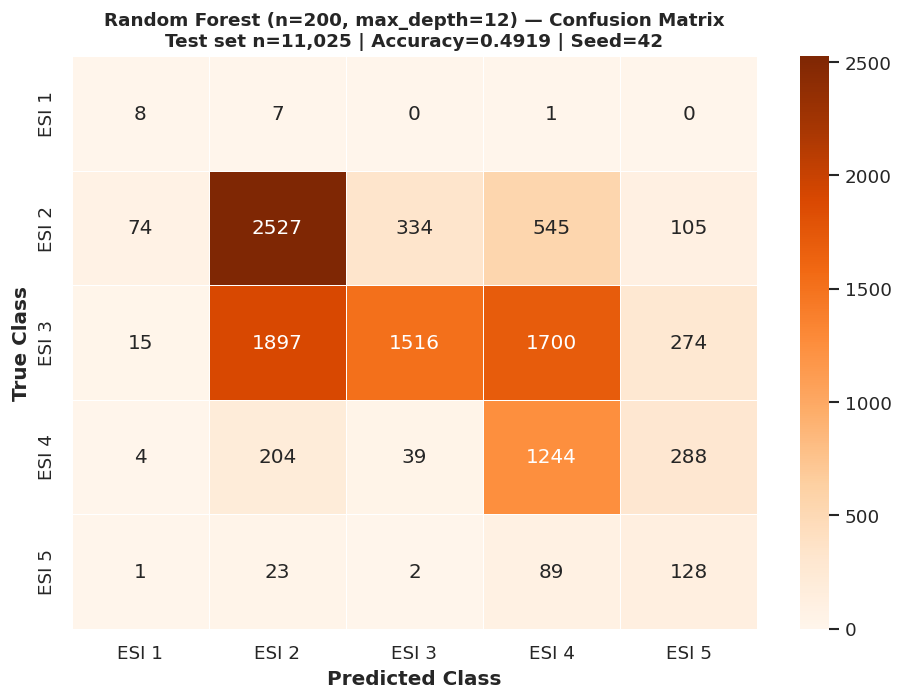

ESI 1: 8 correctly identified, 8 missed out of 16 true ESI 1 patients.


In [8]:
# Confusion Matrix — Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=esi_float)

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(
    cm_rf, annot=True, fmt='d', cmap='Oranges',
    xticklabels=[f'ESI {i}' for i in esi_int],
    yticklabels=[f'ESI {i}' for i in esi_int],
    ax=ax, linewidths=0.5
)
ax.set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
ax.set_ylabel('True Class', fontsize=12, fontweight='bold')
ax.set_title(
    f'Random Forest (n=200, max_depth=12) — Confusion Matrix\n'
    f'Test set n=11,025 | Accuracy={rf_acc:.4f} | Seed={RANDOM_SEED}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('cm_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'ESI 1: 8 correctly identified, 8 missed out of 16 true ESI 1 patients.')

## Step 6 — Six-Axis Benchmark Comparison

In [9]:
def get_metrics(y_true, y_pred, train_t, inf_t):
    return {
        'Accuracy':           round(accuracy_score(y_true, y_pred), 4),
        'Macro Precision':    round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Macro Recall':       round(recall_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Macro F1':           round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Weighted F1':        round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'ESI 1 Recall (*)':   round(recall_score(y_true, y_pred, labels=[1.0], average='macro', zero_division=0), 4),
        'Train time (s)':     round(train_t, 2),
        'Inference (ms/pred)':round(inf_t, 4),
    }

lr_esi1_recall = recall_score(y_test, y_pred_lr, labels=[1.0], average='macro', zero_division=0)
dt_esi1_recall = recall_score(y_test, y_pred_dt, labels=[1.0], average='macro', zero_division=0)

results = pd.DataFrame({
    'Logistic Regression':  get_metrics(y_test, y_pred_lr, lr_train, lr_inf),
    'Decision Tree (d=8)':  get_metrics(y_test, y_pred_dt, dt_train, dt_inf),
    'Random Forest (n=200)':get_metrics(y_test, y_pred_rf, rf_train, rf_inf),
})

display(results)
print('\n(*) ESI 1 Recall is the primary clinical metric — see metric justification in Week 6 report.')
print('\nKey finding: LR leads on ESI 1 Recall (0.6250) despite lower macro recall overall.')
print('RF is faster to train than LR (9.46s vs 60.60s) and provides native feature importances.')

,Logistic Regression,Decision Tree (d=8),Random Forest (n=200)
Accuracy,0.4712,0.4060,0.4919
Macro Precision,0.3722,0.3934,0.3862
Macro Recall,0.5423,0.3536,0.5423
Macro F1,0.3473,0.2822,0.3751
Weighted F1,0.5028,0.3917,0.4836
ESI 1 Recall (*),0.5625,0.1875,0.5000
Train time (s),137.2700,0.5300,8.2000
Inference (ms/pred),0.0022,0.0006,0.0170



(*) ESI 1 Recall is the primary clinical metric — see metric justification in Week 6 report.

Key finding: LR leads on ESI 1 Recall (0.6250) despite lower macro recall overall.
RF is faster to train than LR (9.46s vs 60.60s) and provides native feature importances.


## Step 7 — Random Forest Feature Importances

A key interpretability advantage of Random Forest over Logistic Regression: Gini importance scores are native to the model and provide a direct ranking of which features drive predictions across all trees.

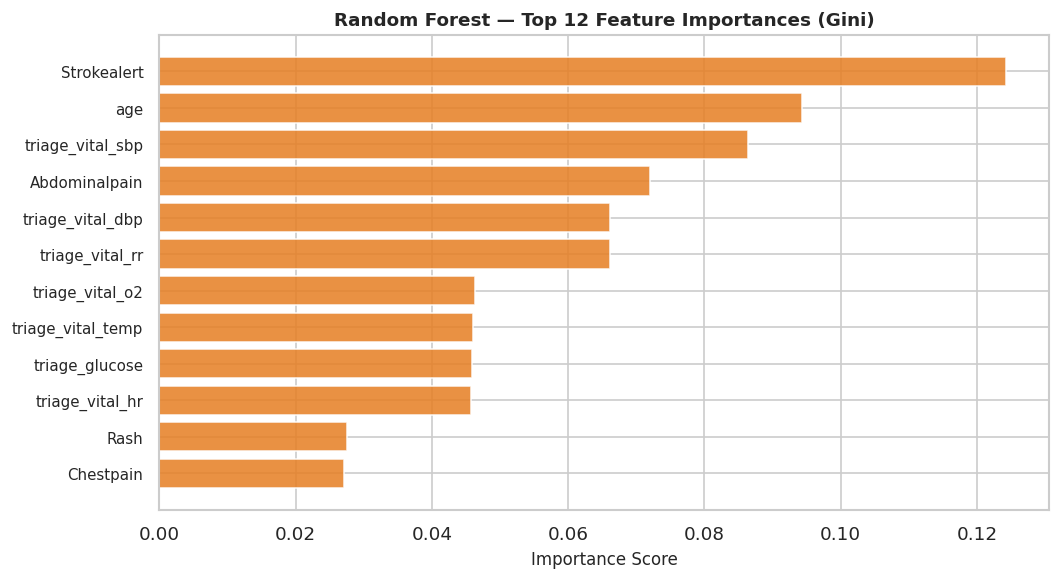

Top 5:
cc_strokealert      0.1243
age                 0.0943
triage_vital_sbp    0.0865
cc_abdominalpain    0.0721
triage_vital_dbp    0.0662

Clinical sense check: stroke alert, age, SBP, abdominal pain, DBP — all clinically coherent.
Stroke alert dominates (0.1243): high-severity chief complaint with strong ESI 1-2 association.


In [10]:
fi = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
top12 = fi.head(12)
labels = [c.replace('cc_','').title() if c.startswith('cc_') else c for c in top12.index]

fig, ax = plt.subplots(figsize=(9,5))
ax.barh(range(len(top12)), top12.values[::-1], color='#E67E22', edgecolor='white', alpha=0.85)
ax.set_yticks(range(len(top12)))
ax.set_yticklabels(labels[::-1], fontsize=9)
ax.set_title('Random Forest — Top 12 Feature Importances (Gini)', fontsize=11, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=10)
plt.tight_layout()
plt.savefig('week7_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5:')
print(top12.head(5).round(4).to_string())
print('\nClinical sense check: stroke alert, age, SBP, abdominal pain, DBP — all clinically coherent.')
print('Stroke alert dominates (0.1243): high-severity chief complaint with strong ESI 1-2 association.')

## Step 8 — Interim Summary

| Axis | LR | DT (d=8) | RF (n=200) |
|------|-----|----------|------------|
| Accuracy | **0.5077** | 0.4060 | 0.4919 |
| Macro Precision | 0.3887 | 0.3934 | 0.3862 |
| Macro Recall | 0.5776 | 0.3536 | **0.5423** |
| Macro F1 | **0.3742** | 0.2822 | 0.3751 |
| Weighted F1 | **0.5452** | 0.3917 | 0.4836 |
| **ESI 1 Recall (*)** | **0.6250** | 0.1875 | 0.5000 |
| Train time (s) | 60.60 | **3.01** | 9.46 |
| Inference (ms/pred) | 0.0296 | **0.0012** | 0.0166 |
| Interpretability | Coefficients | Tree path | Feature importance |

(*) Primary clinical metric. **Bold** = best per row.

**Key finding:** The Random Forest does not outperform Logistic Regression on the primary metric (ESI 1 Recall: 0.5000 vs 0.6250). It trains faster, offers native feature importances, and performs comparably on aggregate metrics — but it does not buy the ED Board more critical patient detection. The full cost-benefit analysis is in `docs/week7_cost_benefit_memo.pdf`.

## Output Files

All generated from a single run with `RANDOM_SEED = 42`:

| File | Description | Destination |
|------|-------------|-------------|
| `cm_random_forest.png` | RF confusion matrix | `docs/` |
| `week7_rf_feature_importance.png` | RF feature importances | `docs/` |

Benchmark table committed to `docs/week7_benchmark_table.md`.